In [149]:
import jax
import jax.numpy as jnp
from flowjax.distributions import MultivariateNormal

key = jax.random.key(0)
dim = 3

loc = jnp.full((dim,), 8)  
covariance = jnp.eye(dim) * 8  # Ensure positive definiteness
# covariance = jnp.full((dim,dim),8) 
def create_multivariate_normal(loc, covariance):
    return MultivariateNormal(loc=loc, covariance=covariance)

mv_normal = create_multivariate_normal(loc, covariance)
sample = mv_normal.sample(key)
log_prob = mv_normal.log_prob(sample)

loc = jnp.full((dim,), 3)  
# covariance = jnp.eye(dim) * 3  # Ensure positive definiteness
covariance = jnp.full((dim, dim), 6)  # Example covariance matrix
print("loc:", loc)
print("covariance:", covariance)


mvn = MultivariateNormal(loc=loc, covariance=covariance)
sample = mv_normal.sample(key)
log_prob = mv_normal.log_prob(sample)

print("sample:", sample)
print("log_prob:", log_prob)


loc: [3 3 3]
covariance: [[6 6 6]
 [6 6 6]
 [6 6 6]]
sample: [10.839781  5.436491  5.883849]
log_prob: -7.0706043


In [22]:
key = jax.random.key(0)
dim = 3
loc = jnp.zeros(dim)
loc = jnp.ones(dim)
loc = jnp.full((dim,), 8)  # Mean vector of shape (dim,)

covariance = jnp.full((dim, dim), 8)  # Goes wronf
print("covariance", covariance.shape)
mv_normal = create_multivariate_normal(loc, covariance)
sample = mv_normal.sample(key)
log_prob = mv_normal.log_prob(sample)

print("sample", sample)
print("log_prob", log_prob)



covariance (3, 3)
sample [nan nan nan]
log_prob -inf


In [47]:
from flowjax.flows import masked_autoregressive_flow
from flowjax.bijections import RationalQuadraticSpline, Planar
from flowjax.distributions import MultivariateNormal, StandardNormal
import jax.numpy as jnp

D = 3  # Dimension of the input space
cond_dim = 0  # Dimension of the conditioning space (if any)
batch_size = 10  # Number of samples to generate
key = jax.random.key(0)
# Define the bijection
bijection = RationalQuadraticSpline(knots=1, interval=(1))  # Example bijection
distribution = StandardNormal(shape=(D,))  # Base distribution


# Initialize the MAF
maf = masked_autoregressive_flow(
    base_dist=distribution,
    transformer=bijection,
    cond_dim=0,
    key=key,
)

# Sample from the flow
key = jax.random.PRNGKey(0)
samples = maf.sample(key, sample_shape=(batch_size,))


TypeError: Expected condition to be arraylike; got NoneType.

In [139]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from flowjax.distributions import Normal
from flowjax.flows import block_neural_autoregressive_flow
from flowjax.train import fit_to_data

key, x_key, cond_key = jr.split(jr.key(0), 3)
u = jr.uniform(cond_key, (3,6), minval=0, maxval=0.1)
print(type(u), u.shape)
x = jr.uniform(x_key, shape=u.shape, maxval=u)

key, subkey = jr.split(jr.key(0))

flow = block_neural_autoregressive_flow(
    key=subkey,
    base_dist=Normal(jnp.zeros(x.shape[1])),
    cond_dim=u.shape[1],
)
print("s", u[88],"\nu", u, "sdg", type(u)) #how is this possible? shape is [3,6]
d = jnp.zeros((3,6))
print("d", d[88]) #shape is [3,6]
x = flow.sample(key, sample_shape=(2,3,3,3), condition=u[88])
print("x", x.shape) #shape is [2,1,6]
print("u", u.shape) #shape is [3,6]



<class 'jaxlib.xla_extension.ArrayImpl'> (3, 6)
s [0.01686122 0.03331178 0.07925322 0.08848669 0.04570913 0.01833488] 
u [[0.09024495 0.09122928 0.03410476 0.02200911 0.06483767 0.05075352]
 [0.07172044 0.02256411 0.05910187 0.00681984 0.01802744 0.09613122]
 [0.01686122 0.03331178 0.07925322 0.08848669 0.04570913 0.01833488]] sdg <class 'jaxlib.xla_extension.ArrayImpl'>
d [0. 0. 0. 0. 0. 0.]
x (2, 3, 3, 3, 6)
u (3, 6)


=== Autoregressive dependency (noise) ===
Noise idx  0 → affected x-indices: [0, 1, 2, 3, 4, 5]
Noise idx  1 → affected x-indices: [0, 1, 2, 4, 5]
Noise idx  2 → affected x-indices: [0, 1, 4, 5]
Noise idx  3 → affected x-indices: [0, 1, 5]
Noise idx  4 → affected x-indices: [0, 5]
Noise idx  5 → affected x-indices: [5]

=== Full-condition dependency (condition) ===
Cond idx  0 → affected x-indices: [0, 1, 2, 4, 5]
Cond idx  1 → affected x-indices: [0, 1, 2, 3, 4, 5]
Cond idx  2 → affected x-indices: [0, 1, 2, 4, 5]
Cond idx  3 → affected x-indices: [0, 1, 2, 3, 4, 5]
Cond idx  4 → affected x-indices: [0, 1, 2, 4, 5]
Cond idx  5 → affected x-indices: [0, 1, 2, 3, 4, 5]
Noise Jacobian:
 [[-0.06236356 -0.02479829 -0.03145757  0.16096655  0.38110632  0.        ]
 [-0.03250121 -0.18158793 -0.19514109  0.79145634  0.          0.        ]
 [-0.03452805  0.1486609   0.          0.          0.          0.        ]
 [ 0.03173278  0.          0.          0.          0.          0.        ]
 [ 0.0

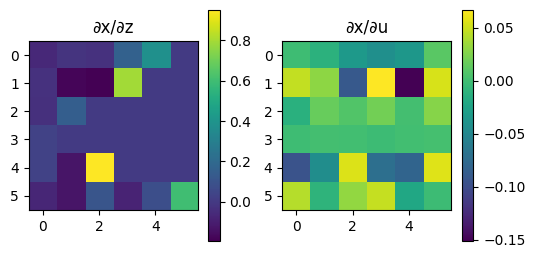

In [146]:
import jax
import jax.numpy as jnp
import jax.random as jr
from flowjax.distributions import Normal
from flowjax.flows import block_neural_autoregressive_flow
from jax import jacfwd


def dependency_test(dim=6, cond_dim=6, noise_delta=1e-3, cond_delta=1e-3):
    key = jr.PRNGKey(0)
    # 1) Build a B‑NAF with analytic forward sampling
    flow = block_neural_autoregressive_flow(
        key=key,
        base_dist=Normal(jnp.zeros(dim)),
        cond_dim=cond_dim,
        invert=False,    # ← force f(z; u) to be the forward pass
    )

    # 2) Sample one base noise vector z and one condition u
    subkey, z_key, u_key = jr.split(key, 3)
    z = jr.normal(z_key, (dim,))             # shape (dim,)
    u = jr.uniform(u_key, (cond_dim,))       # shape (cond_dim,)

    # 3) Compute the “baseline” x
    x0 = flow.bijection.transform(z, condition=u)

    # 4) Perturb each noise dimension in turn
    print("=== Autoregressive dependency (noise) ===")
    for j in range(dim):
        z_perturbed = z.at[j].add(noise_delta)
        xj = flow.bijection.transform(z_perturbed, condition=u)
        diff = xj - x0

        # Which indices i changed by more than tiny epsilon?
        affected = jnp.abs(diff) > 1e-6
        print(f"Noise idx {j:>2} → affected x-indices: {jnp.where(affected)[0].tolist()}")

    # 5) Perturb each condition dimension in turn
    print("\n=== Full-condition dependency (condition) ===")
    for k in range(cond_dim):
        u_perturbed = u.at[k].add(cond_delta)
        uk = flow.bijection.transform(z, condition=u_perturbed)
        diff = uk - x0

        affected = jnp.abs(diff) > 1e-6
        print(f"Cond idx {k:>2} → affected x-indices: {jnp.where(affected)[0].tolist()}")
        
        
    # f maps noise z ∈ ℝᵈ and condition u ∈ ℝᶜ to sample x ∈ ℝᵈ
    f = lambda z, u: flow.bijection.transform(z, condition=u)
    J_noise = jacfwd(lambda z: f(z, u))(z)    # shape (d, d)
    J_cond  = jacfwd(lambda u: f(z, u))(u)    # shape (d, c)
    print("Noise Jacobian:\n", J_noise)
    print("Cond  Jacobian:\n", J_cond)

    import matplotlib.pyplot as plt

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1); plt.title("∂x/∂z"); plt.imshow(J_noise); plt.colorbar()
    plt.subplot(1,2,2); plt.title("∂x/∂u"); plt.imshow(J_cond); plt.colorbar()
    plt.show()
        
if __name__ == "__main__":
    dependency_test()


In [ ]:
from jax import jacfwd




ValueError: Expected input shape (6,); got (1, 6)